In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

print("EDA notebook ready")

EDA notebook ready


In [4]:
df = pd.read_csv('../cleaned-data/master_orders.csv')

# Convert dates properly
df['order_purchase_timestamp'] = pd.to_datetime(
    df['order_purchase_timestamp'],
    dayfirst=True,
    errors='coerce'
)

df['order_delivered_customer_date'] = pd.to_datetime(
    df['order_delivered_customer_date'],
    dayfirst=True,
    errors='coerce'
)

print(f"Shape: {df.shape}")
df.head()

Shape: (119143, 22)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,is_late,...,customer_state,customer_city,product_id,seller_id,price,freight_value,product_category_name_english,payment_type,payment_value,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:00,02-10-2017 11:07,04-10-2017 19:55,2017-10-10 21:25:00,18-10-2017,8.0,0,...,SP,sao paulo,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,housewares,credit_card,18.12,4.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:00,02-10-2017 11:07,04-10-2017 19:55,2017-10-10 21:25:00,18-10-2017,8.0,0,...,SP,sao paulo,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,housewares,voucher,2.00,4.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:00,02-10-2017 11:07,04-10-2017 19:55,2017-10-10 21:25:00,18-10-2017,8.0,0,...,SP,sao paulo,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,housewares,voucher,18.59,4.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:00,26-07-2018 03:24,26-07-2018 14:31,2018-08-07 15:27:00,13-08-2018,13.0,0,...,BA,barreiras,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,118.70,22.76,perfumery,boleto,141.46,4.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:00,08-08-2018 08:55,08-08-2018 13:50,2018-08-17 18:06:00,04-09-2018,9.0,0,...,GO,vianopolis,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,159.90,19.22,auto,credit_card,179.12,5.0


In [6]:
print("=== REVENUE OVERVIEW ===")

print(f"Total Revenue: R${df['payment_value'].sum():,.2f}")

print(f"Total Orders: {df['order_id'].nunique():,}")

print(f"Avg Order Value: R${df['payment_value'].mean():.2f}")

print(
    f"Date Range: "
    f"{df['order_purchase_timestamp'].min()} "
    f"to "
    f"{df['order_purchase_timestamp'].max()}"
)

=== REVENUE OVERVIEW ===
Total Revenue: R$20,579,664.01
Total Orders: 99,441
Avg Order Value: R$172.74
Date Range: 2016-09-04 21:15:00 to 2018-10-17 17:30:00


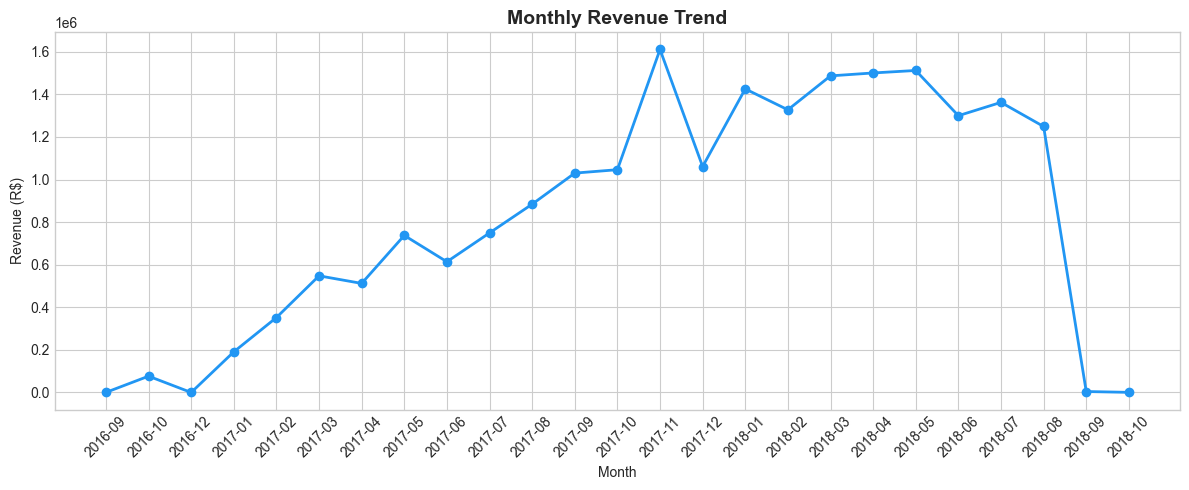

Chart saved


In [7]:
monthly_rev = (
    df.groupby('order_month')['payment_value']
    .sum()
    .reset_index()
)

monthly_rev['order_month'] = monthly_rev['order_month'].astype(str)

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_rev['order_month'],
    monthly_rev['payment_value'],
    marker='o',
    linewidth=2,
    color='#2196F3'
)

plt.title(
    'Monthly Revenue Trend',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Month')
plt.ylabel('Revenue (R$)')
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    '../process-diagrams/monthly_revenue_trend.png',
    dpi=150
)

plt.show()

print("Chart saved")

In [8]:
delivered = df[df['delivery_days'].notna()].copy()

on_time_rate = (delivered['is_late'] == 0).mean() * 100
late_rate = (delivered['is_late'] == 1).mean() * 100

print(f"On-Time Delivery Rate: {on_time_rate:.1f}%")
print(f"Late Delivery Rate: {late_rate:.1f}%")
print(f"Average Delivery Days: {delivered['delivery_days'].mean():.1f}")

On-Time Delivery Rate: 92.2%
Late Delivery Rate: 7.8%
Average Delivery Days: 12.0


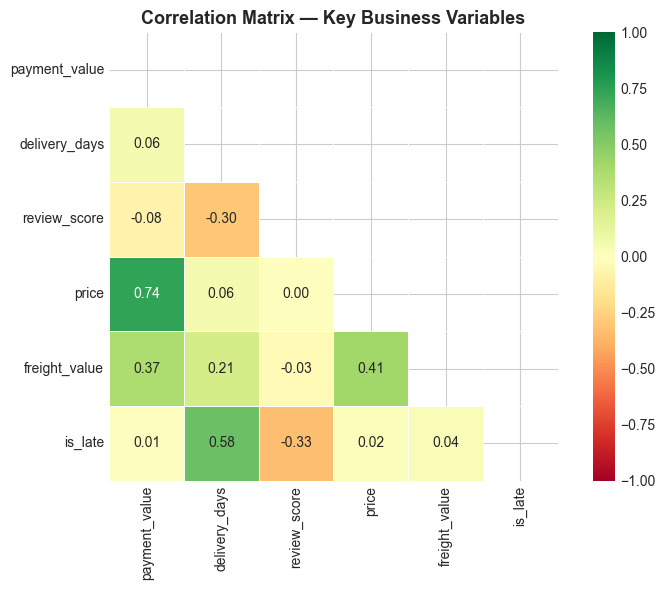

In [9]:
# Select numeric columns for correlation
corr_cols = [
    'payment_value',
    'delivery_days',
    'review_score',
    'price',
    'freight_value',
    'is_late'
]

corr_df = df[corr_cols].dropna()

corr_matrix = corr_df.corr()

plt.figure(figsize=(8, 6))

mask = np.triu(
    np.ones_like(corr_matrix, dtype=bool)
)

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    mask=mask,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True
)

plt.title(
    'Correlation Matrix — Key Business Variables',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    '../process-diagrams/correlation_heatmap.png',
    dpi=150
)

plt.show()

In [10]:
# Statistical test:
# Does delivery time affect review scores?

clean = df[['delivery_days', 'review_score']].dropna()

r, p = stats.pearsonr(
    clean['delivery_days'],
    clean['review_score']
)

print(f"Pearson r = {r:.4f}")
print(f"P-value = {p:.6f}")

if p < 0.05:
    print(
        "STATISTICALLY SIGNIFICANT: "
        "Delivery time is significantly correlated "
        "with review score"
    )

    print(
        f"Interpretation: Longer deliveries "
        f"are associated with "
        f"{'lower' if r < 0 else 'higher'} "
        f"review scores"
    )

Pearson r = -0.3027
P-value = 0.000000
STATISTICALLY SIGNIFICANT: Delivery time is significantly correlated with review score
Interpretation: Longer deliveries are associated with lower review scores


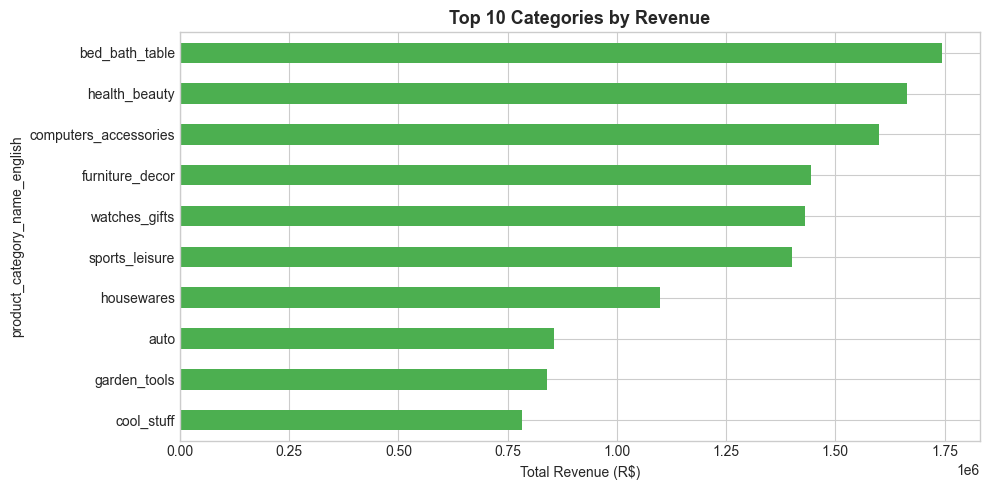

In [11]:
# Top categories by revenue

top_cats = (
    df.groupby('product_category_name_english')
    ['payment_value']
    .sum()
    .nlargest(10)
)

plt.figure(figsize=(10, 5))

top_cats.sort_values().plot(
    kind='barh',
    color='#4CAF50'
)

plt.title(
    'Top 10 Categories by Revenue',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('Total Revenue (R$)')
plt.tight_layout()

plt.savefig(
    '../process-diagrams/top_categories.png',
    dpi=150
)

plt.show()

In [12]:
# Payment method distribution

payment_dist = df['payment_type'].value_counts()

print("=== PAYMENT METHOD DISTRIBUTION ===")
print(payment_dist)

payment_percent = (
    df['payment_type']
    .value_counts(normalize=True) * 100
)

print("\n=== PAYMENT METHOD % ===")
print(payment_percent.round(2))

=== PAYMENT METHOD DISTRIBUTION ===
payment_type
credit_card    87776
boleto         23190
voucher         6465
debit_card      1706
not_defined        3
Name: count, dtype: int64

=== PAYMENT METHOD % ===
payment_type
credit_card    73.67
boleto         19.46
voucher         5.43
debit_card      1.43
not_defined     0.00
Name: proportion, dtype: float64


## EDA Key Findings

### 1. Monthly Revenue Trend
Monthly revenue peaked in **November 2017** and remained strong during **March–May 2018**, indicating seasonal purchasing behavior and business growth over time.

### 2. Delivery Performance
**On-Time Delivery Rate: 92.2%**, which is **below** the industry benchmark of **95%**.

**Late Delivery Rate: 7.8%**

Average delivery time was **12 days**, suggesting room for logistics optimization.

### 3. Customer Satisfaction vs Delivery Speed
**Pearson r(delivery_days, review_score) = -0.30**

The relationship is **statistically significant (p < 0.05)**, showing that **longer delivery times are associated with lower customer review scores**.

**Business implication:** Improving logistics and reducing delays can directly improve customer satisfaction.

### 4. Top Revenue Categories
Top 3 product categories by revenue:

1. **bed_bath_table**
2. **health_beauty**
3. **computers_accessories**

These categories contribute the highest revenue and should be prioritized for promotions, inventory planning, and retention strategies.

### 5. Payment Method Insights
**Credit Card** is the dominant payment method, accounting for **73.67% of all transactions**.

Other methods:
- **Boleto:** 19.46%
- **Voucher:** 5.43%
- **Debit Card:** 1.43%

**Business implication:** Payment optimization efforts should prioritize the credit card experience.